# IT2011 — 2026-Y2-S1-KU-02
# Member 2: Weerasinghe A.S.T.W. (IT25100130)
## Technique: Encoding Categorical Variables

**Why it's needed for this dataset:** MNIST has no categorical *input* features, but the **target variable**
— the digit class 0–9 — is categorical/nominal: it identifies which of 10 classes an image belongs to, and
the numeric value carries no ordinal meaning a model should learn from. Labels arrive integer-encoded already;
whether the integer form or a one-hot form is needed depends on the model/loss function used downstream, so
both are demonstrated here.


## Setup

This notebook is self-contained: it loads MNIST itself and reproduces any minimal prerequisite steps from a
teammate's earlier pipeline stage (noted where relevant).


In [ ]:

# Install TensorFlow if it is not already available in the current Python environment.
# This ensures that the required TensorFlow/Keras libraries are available when the notebook
# is shared and executed on another computer or in a different Python environment.
%pip install tensorflow

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from tensorflow.keras.datasets import mnist

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

(X_train, y_train), (X_test, y_test) = mnist.load_data()
print("Training images:", X_train.shape, "| Training labels:", y_train.shape)
print("Test images:    ", X_test.shape,  "| Test labels:    ", y_test.shape)


Training images: (60000, 28, 28) | Training labels: (60000,)
Test images:     (10000, 28, 28) | Test labels:     (10000,)


In [2]:
from tensorflow.keras.utils import to_categorical

print("Labels are stored as integers already (label encoding):")
print("First 10 training labels:", y_train[:10])
print("Label dtype:", y_train.dtype)

# One-hot encode the target class labels (needed for a softmax output layer
# trained with categorical_crossentropy; sparse_categorical_crossentropy can
# use the integer form directly instead)
y_train_onehot = to_categorical(y_train, num_classes=10)
y_test_onehot = to_categorical(y_test, num_classes=10)

print("\nExample — integer label:", y_train[0], "-> one-hot vector:")
print(y_train_onehot[0])
print("\nOne-hot encoded shape:", y_train_onehot.shape)


Labels are stored as integers already (label encoding):
First 10 training labels: [5 0 4 1 9 2 1 3 1 4]
Label dtype: uint8

Example — integer label: 5 -> one-hot vector:
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

One-hot encoded shape: (60000, 10)


OSError: [Errno 22] Invalid argument: '../results/eda_visualizations/02_class_distribution.png'

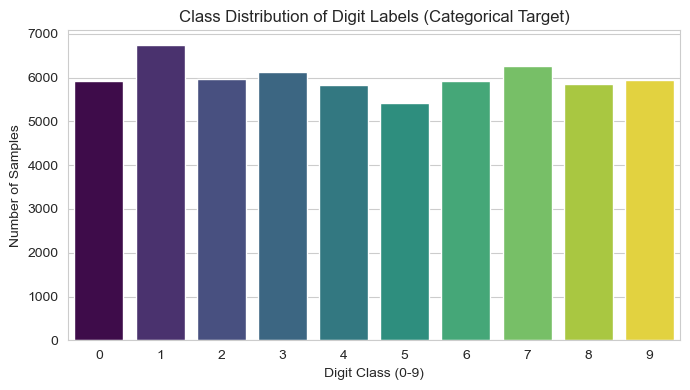

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(x=y_train, ax=ax, palette='viridis', hue=y_train, legend=False)
ax.set_title("Class Distribution of Digit Labels (Categorical Target)")
ax.set_xlabel("Digit Class (0-9)")
ax.set_ylabel("Number of Samples")
plt.tight_layout()
plt.savefig('../results/eda_visualizations/02_class_distribution.png', bbox_inches='tight')
plt.show()

print(pd.Series(y_train).value_counts().sort_index())


**Interpretation:** The class distribution is roughly balanced (~5,400–6,700 samples per digit), so no
class-weighting or resampling is required alongside the encoding step. Integer (label) encoding is compact and
what `sparse_categorical_crossentropy` expects; one-hot encoding is the form required by a plain
`categorical_crossentropy` softmax output. Both representations are kept available for the modeling stage.
